In [1]:
import csv
import gzip
import os
import scipy.io
import numpy as np 
import anndata
os.environ['KMP_DUPLICATE_LIB_OK']='True'
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import scanpy
import seaborn as sns

import sys
sys.path.insert(0,'/users/benauerbach/desktop/sc_phase_inference/src/preprocessing')
import data_encoding


/anaconda2/envs/scrublet/lib/python3.8/site-packages/umap/__init__.py:9: UserWarning: Tensorflow not installed; ParametricUMAP will be unavailable
  warn("Tensorflow not installed; ParametricUMAP will be unavailable")


In [154]:
# import torch

# path = '/Users/benauerbach/Dropbox/aorta_circadian_data/datasets/joint/data_annotations/hvg/connected/scvi_res/scvi_model_torch.pt/model_params.pt'

# torch.load(path).keys()




odict_keys(['px_r', 'z_encoder.encoder.fc_layers.Layer 0.0.weight', 'z_encoder.encoder.fc_layers.Layer 0.0.bias', 'z_encoder.encoder.fc_layers.Layer 1.0.weight', 'z_encoder.encoder.fc_layers.Layer 1.0.bias', 'z_encoder.mean_encoder.weight', 'z_encoder.mean_encoder.bias', 'z_encoder.var_encoder.weight', 'z_encoder.var_encoder.bias', 'l_encoder.encoder.fc_layers.Layer 0.0.weight', 'l_encoder.encoder.fc_layers.Layer 0.0.bias', 'l_encoder.mean_encoder.weight', 'l_encoder.mean_encoder.bias', 'l_encoder.var_encoder.weight', 'l_encoder.var_encoder.bias', 'decoder.px_decoder.fc_layers.Layer 0.0.weight', 'decoder.px_decoder.fc_layers.Layer 0.0.bias', 'decoder.px_decoder.fc_layers.Layer 1.0.weight', 'decoder.px_decoder.fc_layers.Layer 1.0.bias', 'decoder.px_scale_decoder.0.weight', 'decoder.px_scale_decoder.0.bias', 'decoder.px_r_decoder.weight', 'decoder.px_r_decoder.bias', 'decoder.px_dropout_decoder.weight', 'decoder.px_dropout_decoder.bias'])

In [13]:
# --- INIT ---

# adata path
adata_path = '/Users/benauerbach/Dropbox/aorta_circadian_data/datasets/joint/adata_qc_filtered.h5ad'


# muredach hvg
muredach_hvg_path = '/users/benauerbach/dropbox/aorta_circadian_data/muredach_hv_genes.txt'
with open(muredach_hvg_path) as file_obj:
    muredach_hvg = list(map(lambda x: x.replace("\n", ""), file_obj.readlines()))

    
    
# num of significant genes correlation threshold
num_signif_corr_thresh = 500

# min library size for high confidence cells
min_lib_size = 10000

# quantile shift for bin ranking
quantile_shift = 100




In [4]:
# --- LOAD ---

adata = anndata.read_h5ad(adata_path)

adata



AnnData object with n_obs × n_vars = 145271 × 32285
    obs: 'sample_id', 'within_experiment_batch_id', 'lib_size', 'sex', 'misaligned', 'zt', 'bmal1_ko', 'batch', 'percent_mito', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mito_qc_pass', 'umi_qc_pass', 'doublet_qc_pass', 'doublet_score', 'qc_pass', 'concat_batch', 'description'
    var: 'ensembl_id', 'n_cells_by_counts-0', 'mean_counts-0', 'log1p_mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'log1p_total_counts-0', 'n_cells_by_counts-1', 'mean_counts-1', 'log1p_mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'log1p_total_counts-1', 'n_cells_by_counts-2', 'mean_counts-2', 'log1p_mean_counts-2', 'pct_dropout_by_counts-2', 'total_counts-2', 'log1p_total_counts-2'

In [5]:
# --- ADD MUREDACH HV GENE INDICATOR ---

muredach_hv_indicator = np.zeros((adata.shape[1]))
muredach_hv_indicator[np.where(np.isin(adata.var_names, muredach_hvg))] = 1
adata.var['muredach_hvg'] = muredach_hv_indicator.astype(bool)
adata.var['muredach_hvg']


index
Xkr4          False
Gm1992        False
Gm19938       False
Gm37381       False
Rp1           False
              ...  
AC124606.1    False
AC133095.2    False
AC133095.1    False
AC234645.1    False
AC149090.1    False
Name: muredach_hvg, Length: 32285, dtype: bool

In [6]:
# --- LIMIT TO THE CELLS THAT PASSED QC ---

adata = adata[adata.obs['qc_pass']]
adata



/anaconda2/envs/scrublet/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)


View of AnnData object with n_obs × n_vars = 145271 × 32285
    obs: 'sample_id', 'within_experiment_batch_id', 'lib_size', 'sex', 'misaligned', 'zt', 'bmal1_ko', 'batch', 'percent_mito', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mito_qc_pass', 'umi_qc_pass', 'doublet_qc_pass', 'doublet_score', 'qc_pass', 'concat_batch', 'description'
    var: 'ensembl_id', 'n_cells_by_counts-0', 'mean_counts-0', 'log1p_mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'log1p_total_counts-0', 'n_cells_by_counts-1', 'mean_counts-1', 'log1p_mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'log1p_total_counts-1', 'n_cells_by_counts-2', 'mean_counts-2', 'log1p_mean_counts-2', 'pct_dropout_by_counts-2', 'total_counts-2', 'log1p_total_counts-2', 'muredach_hvg'

Trying to set attribute `.var` of view, copying.


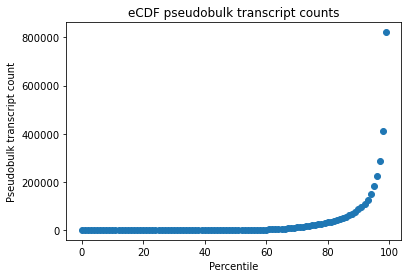

In [7]:
# --- GET PSEUDOBULK COUNTS OF ALL GENES ---

# ** get the gene counts **
pseudobulk_counts = np.array(np.sum(adata.X,axis=0)).flatten() # [num_genes]
adata.var['pseudobulk_counts'] = pseudobulk_counts


# ** viz the eCDF **
percentiles = np.arange(0,100,1)
percentile_vals = np.percentile(pseudobulk_counts,percentiles)


plt.clf()
plt.scatter(percentiles,percentile_vals)
plt.xlabel("Percentile")
plt.ylabel("Pseudobulk transcript count")
plt.title("eCDF pseudobulk transcript counts")
plt.show()





In [8]:
# --- THRESHOLD GENES AT THE MINIMUM ---

# ** params specifying threshold **
min_prop = 1e-3 # minimum expression prop in cell type of interest
min_cells_per_type = 50
median_lib_size = np.median(adata.obs['lib_size'])

# ** determine the threshold **
pseudobulk_threshold = min_prop * min_cells_per_type * median_lib_size

# ** determine genes passing the pseudobulk threshold **
candidate_hvg_indices = np.where(pseudobulk_counts >= pseudobulk_threshold)[0]




In [9]:
# --- RESTRICT ADATA TO THE CANDIDATE HVG ---

candidate_hv_adata = adata[:,candidate_hvg_indices]

candidate_hv_adata



View of AnnData object with n_obs × n_vars = 145271 × 14309
    obs: 'sample_id', 'within_experiment_batch_id', 'lib_size', 'sex', 'misaligned', 'zt', 'bmal1_ko', 'batch', 'percent_mito', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mito_qc_pass', 'umi_qc_pass', 'doublet_qc_pass', 'doublet_score', 'qc_pass', 'concat_batch', 'description'
    var: 'ensembl_id', 'n_cells_by_counts-0', 'mean_counts-0', 'log1p_mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'log1p_total_counts-0', 'n_cells_by_counts-1', 'mean_counts-1', 'log1p_mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'log1p_total_counts-1', 'n_cells_by_counts-2', 'mean_counts-2', 'log1p_mean_counts-2', 'pct_dropout_by_counts-2', 'total_counts-2', 'log1p_total_counts-2', 'muredach_hvg', 'pseudobulk_counts'

In [14]:
# --- GET THE HIGH_LIB_CANDIDATE_HV_ADATA ---


high_lib_candidate_hv_adata = candidate_hv_adata[candidate_hv_adata.obs['lib_size'] >= min_lib_size]
high_lib_candidate_hv_adata




/anaconda2/envs/scrublet/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)


View of AnnData object with n_obs × n_vars = 100425 × 14309
    obs: 'sample_id', 'within_experiment_batch_id', 'lib_size', 'sex', 'misaligned', 'zt', 'bmal1_ko', 'batch', 'percent_mito', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mito_qc_pass', 'umi_qc_pass', 'doublet_qc_pass', 'doublet_score', 'qc_pass', 'concat_batch', 'description'
    var: 'ensembl_id', 'n_cells_by_counts-0', 'mean_counts-0', 'log1p_mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'log1p_total_counts-0', 'n_cells_by_counts-1', 'mean_counts-1', 'log1p_mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'log1p_total_counts-1', 'n_cells_by_counts-2', 'mean_counts-2', 'log1p_mean_counts-2', 'pct_dropout_by_counts-2', 'total_counts-2', 'log1p_total_counts-2', 'muredach_hvg', 'pseudobulk_counts'

In [15]:
# --- LOOK AT THE BREAKDOWN OF CONDITIONS ---

np.unique(high_lib_candidate_hv_adata.obs['description'],return_counts=True)


(array(['female aligned bmal1-control', 'female aligned bmal1-ko',
        'female misaligned bmal1-control', 'male aligned bmal1-control',
        'male aligned bmal1-ko', 'male misaligned bmal1-control'],
       dtype=object),
 array([17068, 13018, 13036, 25950, 17599, 13754]))

In [53]:
# # --- ENCODE AS LOG PROP Z SCORE ---



# high_lib_candidate_hv_adata = data_encoding.log_proportion_z_score(high_lib_candidate_hv_adata)





/anaconda2/envs/scrublet/lib/python3.8/site-packages/umap/__init__.py:9: UserWarning: Tensorflow not installed; ParametricUMAP will be unavailable
  warn("Tensorflow not installed; ParametricUMAP will be unavailable")


In [57]:
# # --- UMAP ---

# import umap

# # ** get X transformed and transposed **
# X_transformed_T = high_lib_candidate_hv_adata.layers['X_transformed'].T

# # ** run UMAP **

# n_components = 2
# n_neighbors = 30
# min_dist = 0.01

# metric = 'euclidean' # bunch of options in documentation
# umap_embedding = umap.UMAP(n_neighbors=n_neighbors,
#                   metric=metric, n_components = n_components).fit_transform(X_transformed_T)





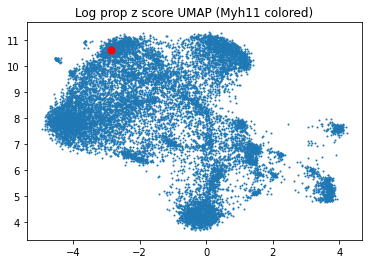

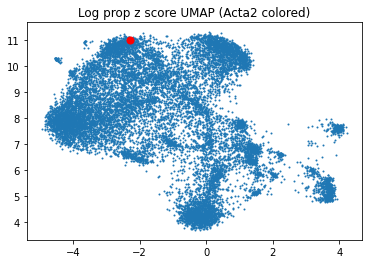

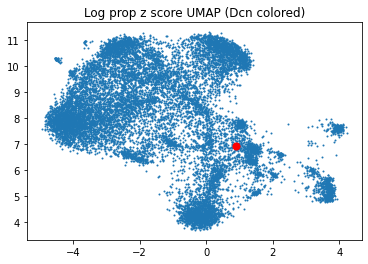

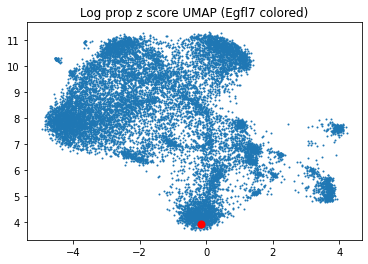

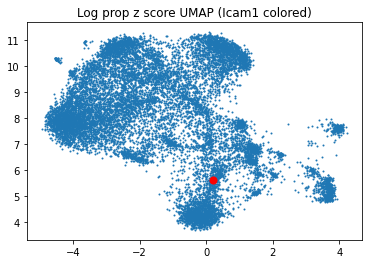

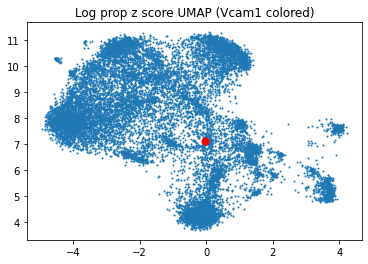

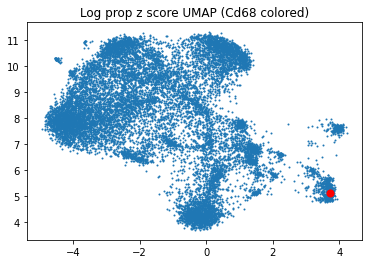

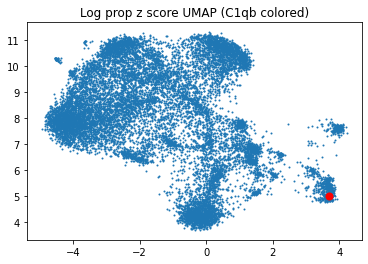

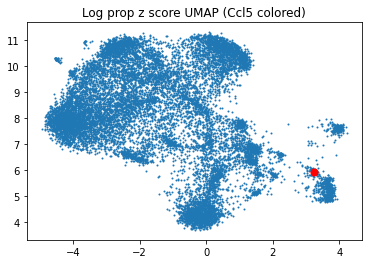

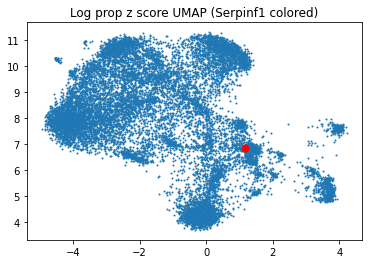

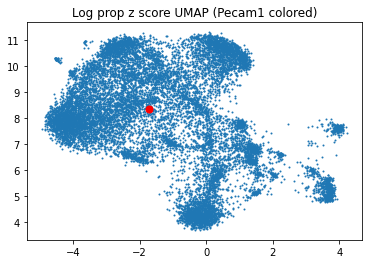

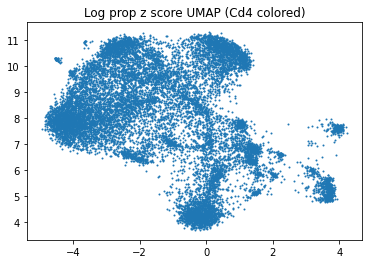

In [67]:
# # --- VIZ MUREDACH MARKERS AND SEE IF MAKE SENSE ---

# genes_of_interest = ['Myh11', 'Acta2', 'Dcn', 'Egfl7', 'Icam1', 'Vcam1', 'Cd68', 'C1qb', 'Ccl5', 'Serpinf1', 'Pecam1', 'Cd4']
# for gene in genes_of_interest:
    
#     try:
#         gene_index = np.where(candidate_hv_adata.var_names == gene)[0]

#         plt.clf()
#         plt.scatter(umap_embedding[:,0], umap_embedding[:,1], s = 1, c = num_signif_correlations_per_gene)
#         plt.scatter(umap_embedding[gene_index,0], umap_embedding[gene_index,1], s = 50, c='r')
#         plt.title("Log prop z score UMAP (%s colored)" % (gene))
#         plt.show()
    
#     except:
#         pass




In [16]:
# --- COMPUTE THE MINIMUM NUMBER OF GENES EXPRESSED IN EACH CELL ---


min_num_genes_detected = np.min(high_lib_candidate_hv_adata.obs['n_genes_by_counts'])

min_num_genes_detected




89

In [17]:
# --- LET'S COMPUTE BINNED GENE RANKS ---

high_lib_candidate_hv_adata = data_encoding.bin_rank(high_lib_candidate_hv_adata,nonzero_cutoff = min_num_genes_detected,quantile_shift=quantile_shift)





In [15]:
# --- COMPUTE THE SPEARMAN RANK MATRIX ---

spearman_res = scipy.stats.spearmanr(high_lib_candidate_hv_adata.layers['X_transformed'],axis=0)
spearman_corr_mat = spearman_res.correlation
spearman_p_value = spearman_res.pvalue
spearman_p_value_test_adjusted = spearman_p_value * (high_lib_candidate_hv_adata.shape[1] ** 2 - high_lib_candidate_hv_adata.shape[1]) / 2




/anaconda2/envs/scrublet/lib/python3.8/site-packages/numpy/lib/function_base.py:2559: RuntimeWarning: invalid value encountered in true_divide
  c /= stddev[:, None]
/anaconda2/envs/scrublet/lib/python3.8/site-packages/numpy/lib/function_base.py:2560: RuntimeWarning: invalid value encountered in true_divide
  c /= stddev[None, :]


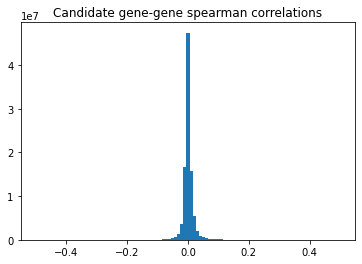

"\n\n# look at particular correlations of interest\ngene_one_index = np.where(candidate_hv_adata.var_names == 'Acta2')\ngene_two_index = np.where(candidate_hv_adata.var_names == 'Myh11')\nspearman_corr_mat[gene_one_index, gene_two_index]\n"

In [16]:
# --- VIZ THE GENE-GENE CORRELATIONS ---

spearman_corr_upper_tri = spearman_corr_mat[np.triu_indices(n = spearman_corr_mat.shape[0], m = spearman_corr_mat.shape[1])]
spearman_corr_upper_tri_non_one = spearman_corr_upper_tri[spearman_corr_upper_tri < 1]

plt.clf()
plt.hist(spearman_corr_upper_tri_non_one, bins = np.linspace(-0.5,0.5,100))
plt.title("Candidate gene-gene spearman correlations")
plt.show()


"""

# look at particular correlations of interest
gene_one_index = np.where(candidate_hv_adata.var_names == 'Acta2')
gene_two_index = np.where(candidate_hv_adata.var_names == 'Myh11')
spearman_corr_mat[gene_one_index, gene_two_index]
"""


In [17]:
# --- BINARIZE ---


# ** make binarized **
spearman_corr_mat_binarized = np.zeros(spearman_corr_mat.shape)
spearman_corr_mat_binarized[np.where(spearman_p_value_test_adjusted <= 0.05)] = 1

# ** make version that just zero's out non-significant **
import copy
spearman_corr_mat_hypothesis_adjusted = copy.deepcopy(spearman_p_value_test_adjusted)
spearman_corr_mat_hypothesis_adjusted[np.where(spearman_p_value_test_adjusted <= 0.05)] = 0



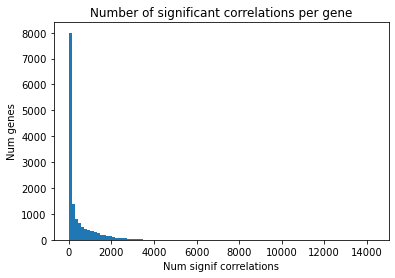

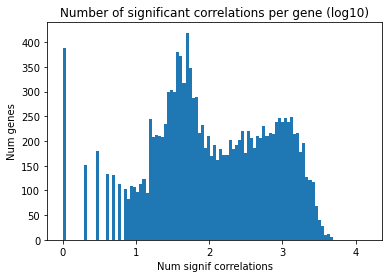

In [18]:
# --- VIZ THE NUMBER OF SIGNIFICANT CORRELATIONS PER GENE ---

num_signif_correlations_per_gene = np.sum(spearman_corr_mat_binarized,axis=0)
high_lib_candidate_hv_adata.var['num_signif_correlations'] = num_signif_correlations_per_gene


plt.clf()
plt.hist((num_signif_correlations_per_gene),np.linspace(0,high_lib_candidate_hv_adata.shape[1],100))
plt.title("Number of significant correlations per gene")
plt.xlabel("Num signif correlations")
plt.ylabel("Num genes")
plt.show()

plt.clf()
plt.hist(np.log10(num_signif_correlations_per_gene + 1),np.linspace(0,np.log10(high_lib_candidate_hv_adata.shape[1]),100))
plt.title("Number of significant correlations per gene (log10)")
plt.xlabel("Num signif correlations")
plt.ylabel("Num genes")
plt.show()



In [21]:
# --- GET THE NUMBER OF SIGNIFICANT CORRELATIONS FOR EACH GENE OF INTEREST ---

for gene in ['Myh11', 'Acta2', 'Dcn', 'Egfl7', 'Icam1', 'Vcam1', 'Cd68', 'C1qb', 'Ccl5', 'Serpinf1', 'Pecam1']:
    try:
        num = high_lib_candidate_hv_adata.var.loc[gene]['num_signif_correlations']
        print(gene,num)
    except:
        pass



Myh11 4548.0
Acta2 4484.0
Dcn 2570.0
Egfl7 2957.0
Icam1 3332.0
Vcam1 2871.0
Cd68 1692.0
C1qb 1250.0
Ccl5 553.0
Serpinf1 2525.0
Pecam1 1694.0


In [ ]:
raise Exception("STOP HERE")




In [24]:
# --- ADD NUM SIGNIF CORRELATIONS AS COL TO ADATA ---

adata.var['num_signif_correlations'] = 0
adata.var.loc[high_lib_candidate_hv_adata.var.index,'num_signif_correlations'] = np.array(high_lib_candidate_hv_adata.var['num_signif_correlations'])





In [25]:
# --- ADD THE CORR MAT TO THE high_lib_candidate_hv_adata ---

high_lib_candidate_hv_adata.varm['signif_corr_mat'] = spearman_corr_mat_binarized

high_lib_candidate_hv_adata


AnnData object with n_obs × n_vars = 18521 × 14309
    obs: 'sample_id', 'within_experiment_batch_id', 'lib_size', 'sex', 'misaligned', 'zt', 'bmal1_ko', 'batch', 'percent_mito', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mito_qc_pass', 'umi_qc_pass', 'doublet_qc_pass', 'doublet_score', 'qc_pass', 'concat_batch', 'description'
    var: 'ensembl_id', 'n_cells_by_counts-0', 'mean_counts-0', 'log1p_mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'log1p_total_counts-0', 'n_cells_by_counts-1', 'mean_counts-1', 'log1p_mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'log1p_total_counts-1', 'n_cells_by_counts-2', 'mean_counts-2', 'log1p_mean_counts-2', 'pct_dropout_by_counts-2', 'total_counts-2', 'log1p_total_counts-2', 'muredach_hvg', 'pseudobulk_counts', 'num_signif_correlations'
    varm: 'signif_corr

In [26]:
# --- GET THE HIGH CONNECTIVITY ADATA ---

gene_passes_num_signif_corr_threshold = high_lib_candidate_hv_adata.var['num_signif_correlations'] >= num_signif_corr_thresh
high_lib_candidate_hv_high_connect_adata = high_lib_candidate_hv_adata[:,gene_passes_num_signif_corr_threshold]

high_lib_candidate_hv_high_connect_adata


/anaconda2/envs/scrublet/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)


View of AnnData object with n_obs × n_vars = 18521 × 3819
    obs: 'sample_id', 'within_experiment_batch_id', 'lib_size', 'sex', 'misaligned', 'zt', 'bmal1_ko', 'batch', 'percent_mito', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mito_qc_pass', 'umi_qc_pass', 'doublet_qc_pass', 'doublet_score', 'qc_pass', 'concat_batch', 'description'
    var: 'ensembl_id', 'n_cells_by_counts-0', 'mean_counts-0', 'log1p_mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'log1p_total_counts-0', 'n_cells_by_counts-1', 'mean_counts-1', 'log1p_mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'log1p_total_counts-1', 'n_cells_by_counts-2', 'mean_counts-2', 'log1p_mean_counts-2', 'pct_dropout_by_counts-2', 'total_counts-2', 'log1p_total_counts-2', 'muredach_hvg', 'pseudobulk_counts', 'num_signif_correlations'
    varm: 'sign

In [28]:
# --- GET THE HIGH CONNECTIVITY CORR MAT ---


# ** get the adata of genes that meet the significant corr **
gene_passes_num_signif_corr_threshold = high_lib_candidate_hv_adata.var['num_signif_correlations'] >= num_signif_corr_thresh

# ** add the corr mat itself to the adata **
signif_corr_gene_indices = np.where(np.array(gene_passes_num_signif_corr_threshold))[0]
signif_corr_mat = spearman_corr_mat_binarized[signif_corr_gene_indices,:][:,signif_corr_gene_indices]

# ** add signif corr mat **
high_connect_corr_mat = signif_corr_mat
high_lib_candidate_hv_high_connect_adata.varm['signif_corr_mat'] = high_connect_corr_mat





In [29]:
# --- COMPUTE UMAP OF JACCARD SIM MATRIX ---


import umap

n_components = 2
n_neighbors = 30
min_dist = 0.01

# run
metric = 'jaccard' # bunch of options in documentation
umap_embedding_jaccard = umap.UMAP(n_neighbors=n_neighbors,
                  metric=metric, n_components = n_components, min_dist = min_dist).fit_transform(high_connect_corr_mat)






/anaconda2/envs/scrublet/lib/python3.8/site-packages/umap/umap_.py:1761: UserWarning: gradient function is not yet implemented for jaccard distance metric; inverse_transform will be unavailable
  warn(


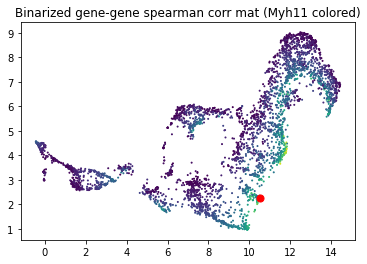

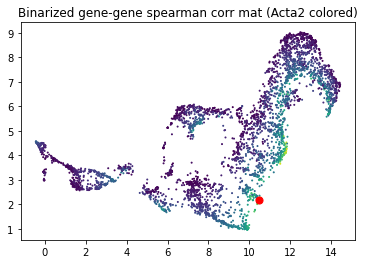

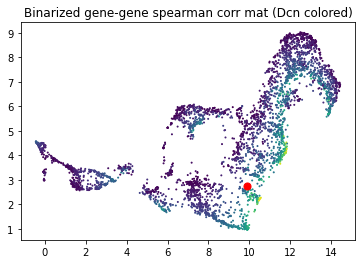

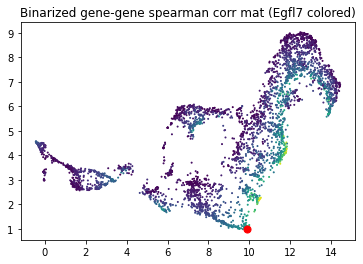

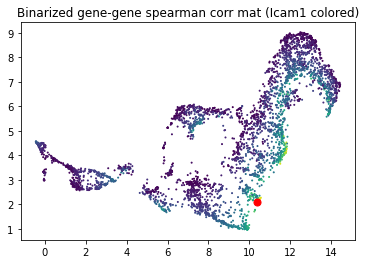

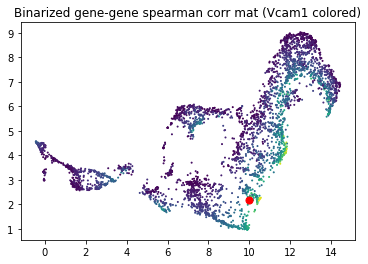

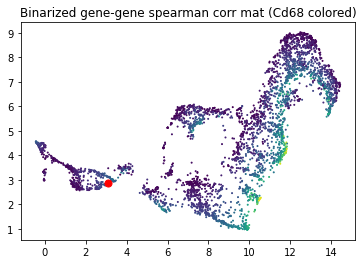

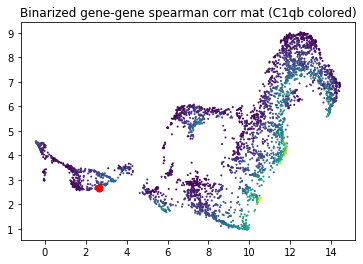

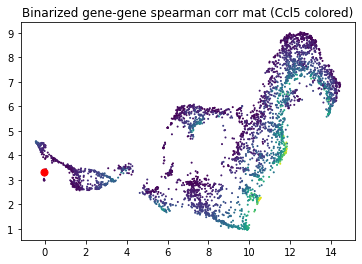

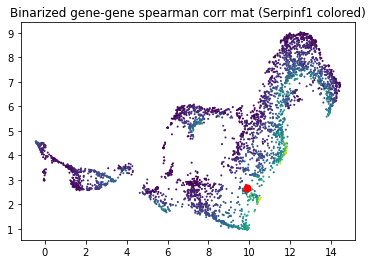

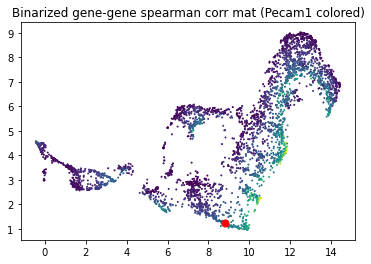

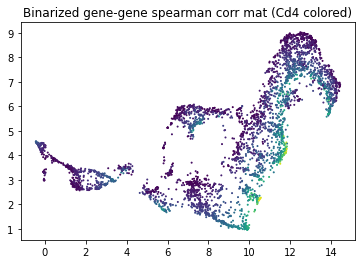

In [30]:
# --- VIZ THE CORR MAT COLORED BY GENES OF INTEREST ---



genes_of_interest = ['Myh11', 'Acta2', 'Dcn', 'Egfl7', 'Icam1', 'Vcam1', 'Cd68', 'C1qb', 'Ccl5', 'Serpinf1', 'Pecam1', 'Cd4']
for gene in genes_of_interest:
    
    try:
        gene_index = np.where(high_lib_candidate_hv_high_connect_adata.var_names == gene)[0]

        plt.clf()
        plt.scatter(umap_embedding_jaccard[:,0], umap_embedding_jaccard[:,1], s = 1, c = high_lib_candidate_hv_high_connect_adata.var['num_signif_correlations'])
        plt.scatter(umap_embedding_jaccard[gene_index,0], umap_embedding_jaccard[gene_index,1], s = 50, c='r')
        plt.title("Binarized gene-gene spearman corr mat (%s colored)" % (gene))
        plt.show()
    
    except:
        pass




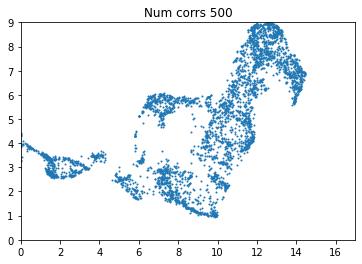

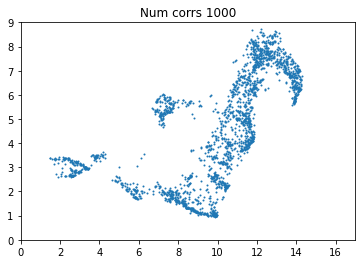

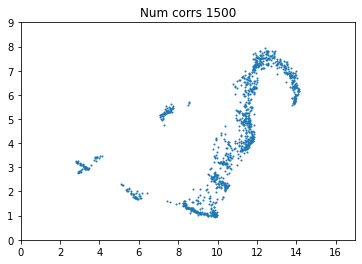

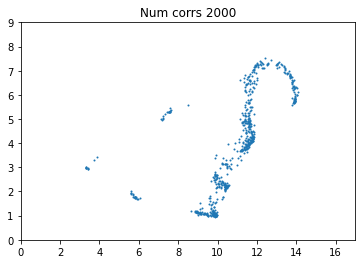

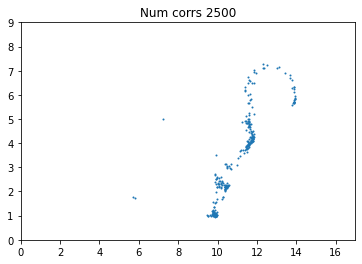

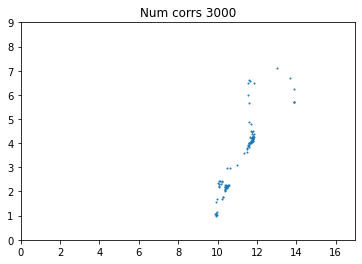

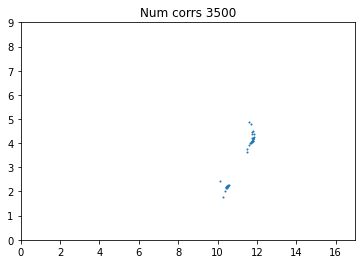

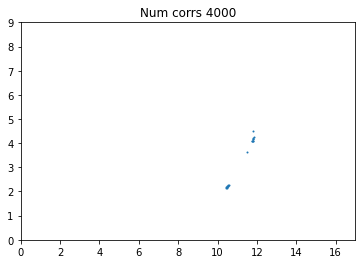

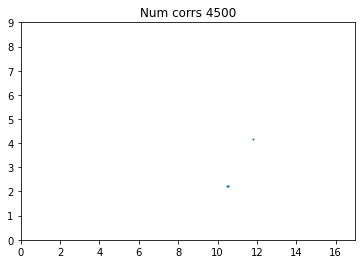

In [31]:
# --- VIZ THE GENE CORR MAT AT DIFFERENT LEVELS OF NUM SIGNIF CORRS ---

for num_corr_thresh in np.arange(500,5000,500):
    passing_indices = np.where(high_lib_candidate_hv_high_connect_adata.var['num_signif_correlations'] >= num_corr_thresh)[0]
    umap_embedding_jaccard_thresh = umap_embedding_jaccard[passing_indices,:]


    plt.clf()
    plt.scatter(umap_embedding_jaccard_thresh[:,0], umap_embedding_jaccard_thresh[:,1], s = 1)
    plt.xlim((0,17))
    plt.ylim((0,9))
    plt.title("Num corrs %s" % num_corr_thresh)
    plt.show()

    
    

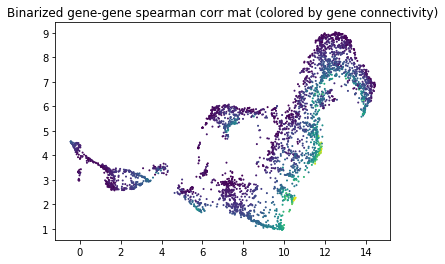

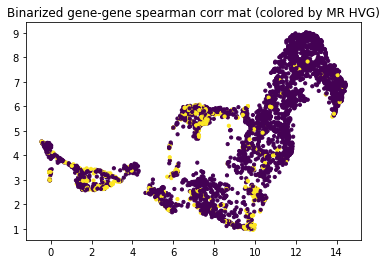

In [32]:
# --- VIZ CORRESPONSE BETWEEN GENE CONNECTIVITY AND MUREDACH MARKERS ---

plt.clf()
plt.scatter(umap_embedding_jaccard[:,0], umap_embedding_jaccard[:,1], s = 1, c = high_lib_candidate_hv_high_connect_adata.var['num_signif_correlations'])
plt.scatter(umap_embedding_jaccard[gene_index,0], umap_embedding_jaccard[gene_index,1], s = 50, c='r')
plt.title("Binarized gene-gene spearman corr mat (colored by gene connectivity)")
plt.show()


plt.clf()
plt.scatter(umap_embedding_jaccard[:,0], umap_embedding_jaccard[:,1], s = 10, c = high_lib_candidate_hv_high_connect_adata.var['muredach_hvg'])
plt.scatter(umap_embedding_jaccard[gene_index,0], umap_embedding_jaccard[gene_index,1], s = 50, c='r')
plt.title("Binarized gene-gene spearman corr mat (colored by MR HVG)")
plt.show()






In [33]:
# --- LOOK AT THE TOP GENES IN REGION ---

umap1_min,umap1_max = 10.5,12.2
umap2_min,umap2_max = 3.5,6

gene_indices = np.where((umap_embedding_jaccard[:,0] >= umap1_min) & (umap_embedding_jaccard[:,0] <= umap1_max) & (umap_embedding_jaccard[:,1] >= umap2_min) & (umap_embedding_jaccard[:,1] <= umap2_max))[0]

subset_adata = high_lib_candidate_hv_high_connect_adata[:,gene_indices]
subset_adata.var['num_signif_correlations'].sort_values(ascending=False).index




/anaconda2/envs/scrublet/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)


Index(['Map1b', 'Pcdh7', 'Ppp1r12a', 'Tpm1', 'Dmd', 'Dst', 'Mylk', 'Lpp',
       'Tns1', 'Rock1',
       ...
       'Rpl4', 'Ppdpf', 'Tmem109', 'Sys1', 'Rps27rt', 'Pcmtd1', 'Tmed4',
       'Scpep1', 'Rab10', 'Sec31a'],
      dtype='object', name='index', length=365)

In [41]:

sys.getsizeof(spearman_corr_mat_binarized) / (1e9)



1.63797996

In [43]:
sys.getsizeof(spearman_corr_mat_binarized_sparse) / (1e9)


4.8e-08

In [42]:
# --- WRITE THE NUM SIGNIF CORRELATIONS MAT ---

from scipy import sparse

spearman_corr_mat_binarized_sparse = sparse.csr_matrix(spearman_corr_mat_binarized)





In [ ]:
# --- WRITE THE BINARIZED CORR MAT ---

sys.getsizeof(spearman_corr_mat_binarized_sparse) / (1e9)




In [342]:
# --- WRITE ADATA ---
adata.var['num_signif_correlations'].astype(int)
# adata.write(adata_fileout)



In [55]:
adata_subset = adata

adata_subset



AnnData object with n_obs × n_vars = 145271 × 32285
    obs: 'sample_id', 'within_experiment_batch_id', 'lib_size', 'sex', 'misaligned', 'zt', 'bmal1_ko', 'batch', 'percent_mito', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mito_qc_pass', 'umi_qc_pass', 'doublet_qc_pass', 'doublet_score', 'qc_pass', 'concat_batch', 'description'
    var: 'ensembl_id', 'n_cells_by_counts-0', 'mean_counts-0', 'log1p_mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'log1p_total_counts-0', 'n_cells_by_counts-1', 'mean_counts-1', 'log1p_mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'log1p_total_counts-1', 'n_cells_by_counts-2', 'mean_counts-2', 'log1p_mean_counts-2', 'pct_dropout_by_counts-2', 'total_counts-2', 'log1p_total_counts-2', 'muredach_hvg', 'pseudobulk_counts', 'num_signif_correlations'

In [61]:
adata_subset = adata[adata.obs['sample_id'] == 106402]
adata_subset



/anaconda2/envs/scrublet/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)


View of AnnData object with n_obs × n_vars = 5345 × 32285
    obs: 'sample_id', 'within_experiment_batch_id', 'lib_size', 'sex', 'misaligned', 'zt', 'bmal1_ko', 'batch', 'percent_mito', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mito_qc_pass', 'umi_qc_pass', 'doublet_qc_pass', 'doublet_score', 'qc_pass', 'concat_batch', 'description'
    var: 'ensembl_id', 'n_cells_by_counts-0', 'mean_counts-0', 'log1p_mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'log1p_total_counts-0', 'n_cells_by_counts-1', 'mean_counts-1', 'log1p_mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'log1p_total_counts-1', 'n_cells_by_counts-2', 'mean_counts-2', 'log1p_mean_counts-2', 'pct_dropout_by_counts-2', 'total_counts-2', 'log1p_total_counts-2', 'muredach_hvg', 'pseudobulk_counts', 'num_signif_correlations'

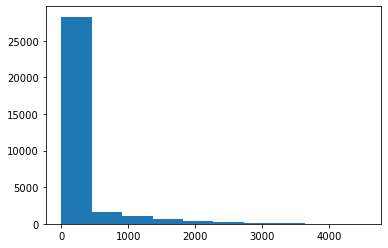

,num_signif_correlations
gene,
Myh11,4548.0
Acta2,4484.0
Dcn,2570.0
Egfl7,2957.0
Icam1,3332.0
Vcam1,2871.0
Cd68,1692.0
C1qb,1250.0
Ccl5,553.0


In [134]:



genes_of_interest = ['Myh11', 'Acta2', 'Dcn', 'Egfl7', 'Icam1', 'Vcam1', 'Cd68', 'C1qb', 'Ccl5', 'Serpinf1', 'Pecam1']
 

plt.clf()
plt.hist(num_signif_corr_df['num_signif_correlations'])
plt.show()


num_signif_corr_df.sort_values(['num_signif_correlations'],ascending=False).loc[genes_of_interest]



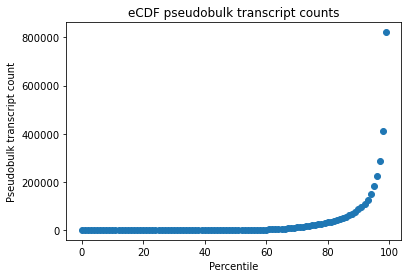

/anaconda2/envs/scrublet/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)
/anaconda2/envs/scrublet/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)
/anaconda2/envs/scrublet/lib/python3.8/site-packages/numpy/lib/function_base.py:2559: RuntimeWarning: invalid value encountered in true_divide
  c /= stddev[:, None]
/anaconda2/envs/scrublet/lib/python3.8/site-packages/numpy/lib/function_base.py:2560: RuntimeWarning: invalid value encountered in true_divide
  c /= stddev[None, :]


In [96]:
# --- RUN HVG COMMUNITY DETECTION ---

sys.path.insert(0,'/users/benauerbach/desktop')
import test_feature_selection
import importlib
importlib.reload(test_feature_selection)
num_signif_corr_df, candidate_hvg_spearman_corr_mat_binarized, candidate_hv_genes = test_feature_selection.select_hvg_based_on_connectivity(adata,num_signif_corr_thresh = 500, min_lib_size = 20000, quantile_shift = 100)






In [ ]:
# --- SPARSEN UP candidate_hvg_spearman_corr_mat_binarized ---
candidate_hvg_spearman_corr_mat_binarized_sparse = scipy.sparse.csr_matrix(candidate_hvg_spearman_corr_mat_binarized)                              





In [147]:
# --- WRITE OUT ---

# num signif corr df
folder_out = '/Users/benauerbach/Dropbox/aorta_circadian_data/datasets/joint/data_annotations/hvg/connected'
fileout = '%s/candidate_hvg_num_signif_corr.tsv' % folder_out
num_signif_corr_df.to_csv(fileout,sep='\t')


# hvg
signif_corr_gene_df = num_signif_corr_df[num_signif_corr_df['num_signif_correlations'] >= 300]
signif_corr_genes = list(np.array(signif_corr_gene_df.index))
fileout = '%s/hvg.txt' % folder_out
with open(fileout,'wb') as file_obj:
    file_obj.write("\n".join(signif_corr_genes).encode())

# candidate hvg
fileout = '%s/candidate_hvg.txt' % folder_out
with open(fileout,'wb') as file_obj:
    file_obj.write("\n".join(list(candidate_hv_genes)).encode())
    

# candidate hvg binary signif corr mat
fileout = '%s/candidate_hvg_signif_spearman_corr_mat_binarized.npz' % folder_out
scipy.sparse.save_npz(fileout, candidate_hvg_spearman_corr_mat_binarized_sparse)
    
    